<small>
Introducción a la Ciencia de Datos | Posgrado en Ciencias de la Computación — CICESE  
Práctica 1: Análisis Exploratorio y Visualización
</small>

---

# Conjunto de Datos de SOP (PCOS Dataset)

Este conjunto de datos proviene de [Kaggle](https://www.kaggle.com/datasets/cm037divya/pcos-dataset/data). Contiene **2,000 registros** distribuidos en **44 columnas** etiquetadas.

###  Estructura de los Datos

Las columnas incluyen variables antropométricas, hormonales, de estilo de vida y mediciones ecográficas, tales como:

* **Identificadores y datos demográficos:** `'Sl. No'`, `'Patient File No.'`, `'Age (yrs)'`, `'Blood Group'`, `'BMI'`, `'Weight (Kg)'`, `'Height(Cm)'`
* **Diagnóstico principal:** `'PCOS (Y/N)'`
* **Perfil hormonal:** `'FSH(mIU/mL)'`, `'LH(mIU/mL)'`, `'TSH (mIU/L)'`, `'AMH(ng/mL)'`, entre otros.
* **Factores de estilo de vida y clínica:** `'Weight gain(Y/N)'`, `'hair growth(Y/N)'`, `'Skin darkening (Y/N)'`, `'Fast food (Y/N)'`, `'Reg.Exercise(Y/N)'`
* **Mediciones clínicas y ecográficas:** `'BP _Systolic (mmHg)'`, `'BP _Diastolic (mmHg)'`, `'Follicle No. (L)'`, `'Follicle No. (R)'`, `'Endometrium (mm)'`

### Procedencia y Aplicaciones

El conjunto de datos fue publicado por el usuario **cm037divya**. Aunque la descripción original no detalla su procedencia institucional específica, incluye especificaciones orientadas a la investigación médica donde se destaca su utilidad para:

1. **Estudios epidemiológicos:** Analizar la prevalencia y las características clínicas del **Síndrome de Ovario Poliquístico** (PCOS, por sus siglas en inglés).
2. **Modelado predictivo:** Desarrollar e entrenar modelos de *Machine Learning* para la detección temprana de PCOS a partir de síntomas, perfiles hormonales y hábitos de estilo de vida.

### Importación de Librerías

Para comenzar con el análisis, importaremos las librerías necesarias de Python para la manipulación y visualización de los datos.

* **Pandas:** Permite cargar, estructurar y manipular eficientemente el archivo `.csv`.
* **Matplotlib:** Ofrece herramientas gráficas para visualizar las distribuciones y relaciones entre las variables, facilitando la interpretación de los datos.

```python
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
from scipy.stats import mannwhitneyu
images_dir = Path.cwd() / "Images"
images_dir.mkdir(parents=True, exist_ok=True)

filename = "PCOS_extended_dataset.csv"
dataset_path = None
## Esta parte la tuve que resolver con IA, mi problema fue que JNTBK no llegaba al archivo con el path "../Data/PCOS_extended_dataset.csv"
for folder in [Path.cwd(), *Path.cwd().parents]:
    candidates = [
        folder / filename,
        folder / "Datos" / filename,
    ]
    for candidate in candidates:
        if candidate.is_file():
            dataset_path = candidate
            break
    if dataset_path:
        break

if dataset_path is None:
    raise FileNotFoundError(
        f"No se encontró {filename}. Verifica que esté dentro de una carpeta 'Datos'."
    )
## Hasta aqui resolvio.

df = pd.read_csv(dataset_path)
df.columns = df.columns.str.strip()

print(f"Archivo cargado desde: {dataset_path}")

df  


Archivo cargado desde: c:\Users\capim\OneDrive\Escritorio\ICD-2026\Datos\PCOS_extended_dataset.csv


,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
0,193,193,0,30,69.979147,167.708055,23.185569,12,72,22,...,1,0.0,1,105.483401,76.096379,2,4,10.0,13.0,6.176029
1,360,360,0,36,63.711688,154.055877,25.441392,13,70,18,...,1,0.0,1,115.883740,79.117243,2,3,13.0,11.0,6.824718
2,10,10,0,36,51.848631,149.059804,23.928264,15,80,20,...,0,0.0,0,112.219711,80.919417,1,1,14.0,17.0,2.568691
3,278,278,1,29,66.893988,148.628036,27.894935,15,72,18,...,0,0.0,1,104.619624,69.902681,1,1,12.0,14.0,9.962732
4,71,71,0,33,52.536198,150.767409,23.079564,13,72,18,...,0,0.0,0,99.175454,70.330461,5,2,11.5,4.7,6.655190
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,87,87,0,31,66.948922,155.976858,26.662263,15,74,18,...,0,0.0,0,120.323951,83.738573,8,10,15.0,13.0,9.816150
1996,508,508,0,37,64.592788,151.979792,27.681715,11,74,20,...,0,1.0,0,109.738395,76.083303,6,6,19.0,19.0,7.930382
1997,166,166,0,32,47.750129,148.596447,20.041406,11,73,26,...,1,1.0,0,109.570220,61.778231,5,5,14.0,13.0,6.832224
1998,266,266,0,40,31.869660,152.589988,13.793101,15,72,20,...,0,1.0,1,119.456176,79.410616,6,5,18.0,17.0,7.636086


---

### Dimensión del Conjunto de Datos

A continuación, utilizamos la función `df.shape` para determinar las dimensiones del conjunto de datos. Al ejecutar el código, confirmamos que el *dataframe* consta de **2,000 filas** y **44 columnas**. La descripción y el detalle de cada una de estas columnas se abordaron en la primera sección de este documento.

```python
df.shape

In [3]:
df.shape

(2000, 44)

---

### Inspección de la Primera Instancia

Seguidamente, utilizamos la función `df.loc[]` para extraer e inspeccionar los datos registrados del primer sujeto (instancia u objeto) junto con sus respectivos nombres de columna. Esto nos permite observar de forma vertical la estructura y composición detallada del *dataframe*.

```python
df.loc[1]

In [4]:
df.loc[1]

Sl. No                           360
Patient File No.                 360
PCOS (Y/N)                         0
Age (yrs)                         36
Weight (Kg)                63.711688
Height(Cm)                154.055877
BMI                        25.441392
Blood Group                       13
Pulse rate(bpm)                   70
RR (breaths/min)                  18
Hb(g/dl)                        10.5
Cycle(R/I)                         2
Cycle length(days)                 6
Marraige Status (Yrs)           12.0
Pregnant(Y/N)                      1
No. of abortions                   0
I   beta-HCG(mIU/mL)           418.9
II    beta-HCG(mIU/mL)         418.9
FSH(mIU/mL)                     2.85
LH(mIU/mL)                      1.71
FSH/LH                          1.67
Hip(inch)                         38
Waist(inch)                       35
Waist:Hip Ratio                 0.92
TSH (mIU/L)                     1.54
AMH(ng/mL)                      3.09
PRL(ng/mL)                     26.09
V

---

### Selección de la Variable Objetivo

Utilizamos la expresión `df["PCOS (Y/N)"]` para aislar la columna que contiene la variable objetivo (*target*), la cual representa una característica determinante para nuestro análisis. Esta columna codifica de forma binaria si la paciente o instancia dio positivo (`1`) o negativo (`0`) para el diagnóstico del Síndrome de Ovario Poliquístico.

```python
df["PCOS (Y/N)"]

In [5]:
df["PCOS (Y/N)"]

0       0
1       0
2       0
3       1
4       0
       ..
1995    0
1996    0
1997    0
1998    0
1999    1
Name: PCOS (Y/N), Length: 2000, dtype: int64

---

### Verificación de los Tipos de Datos

Utilizamos la propiedad `df.dtypes` para inspeccionar el tipo de dato asignado a cada columna (`int64`, `float64`, `object`, etc.). Esta comprobación es fundamental para verificar que las variables numéricas y categóricas estén correctamente tipificadas antes de realizar operaciones matemáticas, análisis estadísticos o la preparación para modelos de aprendizaje automático.

```python
df.dtypes

In [6]:
df.dtypes

Sl. No                      int64
Patient File No.            int64
PCOS (Y/N)                  int64
Age (yrs)                   int64
Weight (Kg)               float64
Height(Cm)                float64
BMI                       float64
Blood Group                 int64
Pulse rate(bpm)             int64
RR (breaths/min)            int64
Hb(g/dl)                  float64
Cycle(R/I)                  int64
Cycle length(days)          int64
Marraige Status (Yrs)     float64
Pregnant(Y/N)               int64
No. of abortions            int64
I   beta-HCG(mIU/mL)      float64
II    beta-HCG(mIU/mL)        str
FSH(mIU/mL)               float64
LH(mIU/mL)                float64
FSH/LH                    float64
Hip(inch)                   int64
Waist(inch)                 int64
Waist:Hip Ratio           float64
TSH (mIU/L)               float64
AMH(ng/mL)                    str
PRL(ng/mL)                float64
Vit D3 (ng/mL)            float64
PRG(ng/mL)                float64
RBS(mg/dl)    

---

### Resumen Estructural del DataFrame

A continuación, utilizamos el método `df.info()` para obtener una vista general y concisa sobre la estructura del *dataframe*. Esta herramienta nos permite verificar de manera rápida el número total de registros, la lista de columnas con sus respectivos tipos de datos y la presencia de valores no nulos (*non-null counts*) para identificar posibles datos faltantes.

```python
df.info()

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sl. No                  2000 non-null   int64  
 1   Patient File No.        2000 non-null   int64  
 2   PCOS (Y/N)              2000 non-null   int64  
 3   Age (yrs)               2000 non-null   int64  
 4   Weight (Kg)             2000 non-null   float64
 5   Height(Cm)              2000 non-null   float64
 6   BMI                     2000 non-null   float64
 7   Blood Group             2000 non-null   int64  
 8   Pulse rate(bpm)         2000 non-null   int64  
 9   RR (breaths/min)        2000 non-null   int64  
 10  Hb(g/dl)                2000 non-null   float64
 11  Cycle(R/I)              2000 non-null   int64  
 12  Cycle length(days)      2000 non-null   int64  
 13  Marraige Status (Yrs)   1997 non-null   float64
 14  Pregnant(Y/N)           2000 non-null   int64  
 15

---

## Hallazgo y Corrección de Tipos de Datos

### Hallazgo
Al ejecutar el método `df.info()`, se identificó que las columnas **beta-HCG(mIU/mL)** y **AMH(ng/mL)** están clasificadas como tipo texto (`str` / `object`). Dado que representan mediciones numéricas de concentraciones hormonales, deben ser tratadas como números flotantes (`float`) para permitir análisis estadísticos y modelado.

Este problema suele ser provocado por espacios, comas en lugar de puntos decimales o caracteres especiales (como `"<0.1"`, `">2000"`, `"N/A"`).

In [8]:
df.describe(
    include=["object", "str", "bool"]
)

,II beta-HCG(mIU/mL),AMH(ng/mL)
count,2000,2000
unique,200,298
top,1.99,1.2
freq,1136,28


---

## Limpieza y Conversión de Variables Hormonales

### Descripción del Proceso

El código realiza la estandarización y conversión de las columnas de **beta-HCG** y **AMH** desde formato de texto (`str`) a numérico flotante (`float`), solucionando problemas de inconsistencias en la captura de datos.

### Pasos Ejecutados

* **Normalización de Encabezados:** Se eliminan los espacios adicionales al inicio y final de los nombres de las columnas en el DataFrame para evitar errores por caracteres invisibles.
* **Búsqueda Dinámica de Columnas:** Se identifican automáticamente las variables mediante coincidencia parcial de texto (`beta-HCG` y `AMH`), previniendo fallos si los nombres presentan prefijos o espacios internos anormales (ej. `" II    beta-HCG(mIU/mL)"`).
* **Saneamiento de Texto:**
  * Conversión explícita a `str` para permitir manipulación de cadenas.
  * Reemplazo de comas (`,`) por puntos (`.`) para homologar el formato decimal.
  * Extracción con expresiones regulares (`r'(\d+\.?\d*)'`) para remover caracteres no numéricos o símbolos de detección como `"<"` o `">"`.
* **Transformación Tipológica:** Se aplica `pd.to_numeric()` con el argumento `errors='coerce'`, lo que convierte el valor limpiado a `float64` y fuerza a valor nulo (`NaN`) cualquier registro con texto irrecuperable.
* **Renombrado Estructurado:** Se asignan identificadores limpios sin símbolos ni espacios (`beta_HCG_mIU_mL` y `AMH_ng_mL`) para facilitar la sintaxis en futuros análisis y modelado.

In [9]:
# 1. Limpiar los nombres de las columnas (elimina espacios invisibles/extras)
df.columns = df.columns.str.strip()

# 2. Identificar y corregir los nombres exactos de las dos columnas
col_hcg = [c for c in df.columns if 'beta-HCG' in c][0]
col_amh = [c for c in df.columns if 'AMH' in c][0]

cols_a_corregir = [col_hcg, col_amh]

# 3. Aplicar limpieza de texto y conversión a float
for col in cols_a_corregir:
    # Convertir a texto y limpiar espacios
    s = df[col].astype(str).str.strip().str.replace(',', '.')
    
    # Extraer únicamente el valor numérico
    s_numeric = s.str.extract(r'(\d+\.?\d*)')[0]
    
    # Convertir a tipo numérico float 
    df[col] = pd.to_numeric(s_numeric, errors='coerce')

df = df.rename(columns={
    col_hcg: 'beta_HCG_mIU_mL',
    col_amh: 'AMH_ng_mL'
})

# 5. Verificar los nuevos tipos de datos
print("--- Nuevos tipos de datos ---")
print(df[['beta_HCG_mIU_mL', 'AMH_ng_mL']].dtypes)

--- Nuevos tipos de datos ---
beta_HCG_mIU_mL    float64
AMH_ng_mL          float64
dtype: object


### Resultados de la Evaluación de Calidad

* **Duplicados:** Se confirmaron **0 filas duplicadas idénticas** en la totalidad del *dataset*.
* **Valores Faltantes:** El **95.5% de las columnas (42 de 44)** están completamente pobladas (0.00% de nulos). Únicamente dos variables presentan datos faltantes con un impacto mínimo:
  * `AMH_ng_mL`: **0.15%** (3 registros nulos)
  * `Marraige Status (Yrs)`: **0.15%** (3 registros nulos)

In [10]:
# 1. Verificación de duplicados idénticos
duplicados_totales = df.duplicated().sum()
print(f"Filas duplicadas idénticas en el dataset: {duplicados_totales}")
print("----------------------------------------------------------------\n")

# 2. Porcentaje de nulos (filtrando solo las columnas que tienen > 0%)
porcentaje_nulos = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
nulos_existentes = porcentaje_nulos[porcentaje_nulos > 0]

print("Porcentaje de valores nulos:")
print(nulos_existentes)
print("----------------------------------------------------------------\n")

# 3. Eliminar duplicados si los hubiera
df = df.drop_duplicates()

Filas duplicadas idénticas en el dataset: 0
----------------------------------------------------------------

Porcentaje de valores nulos:
AMH_ng_mL                0.15
Marraige Status (Yrs)    0.15
dtype: float64
----------------------------------------------------------------



---

### Estrategia de Tratamiento de Valores Faltantes

Debido a que el volumen de datos nulos representa únicamente el **0.15% del dataset (3 registros)**, se optó por la **imputación por mediana**:

* **`AMH_ng_mL`:** Se reemplazaron los 3 valores ausentes por la mediana de la variable, previniendo el sesgo por valores atípicos extremos característicos de las concentraciones hormonales.
* **`Marraige Status (Yrs)`:** Se imputaron los registros faltantes con la mediana de la columna.

Esta estrategia mantiene la integridad muestral del dataset sin descartar observaciones útiles.

In [11]:
# Imputación de AMH con la mediana
mediana_amh = df['AMH_ng_mL'].median()
df['AMH_ng_mL'] = df['AMH_ng_mL'].fillna(mediana_amh)

# Imputación de Marriage Status con la mediana
mediana_marriage = df['Marraige Status (Yrs)'].median()
df['Marraige Status (Yrs)'] = df['Marraige Status (Yrs)'].fillna(mediana_marriage)

# Verificación
print(f"Nulos restantes en AMH: {df['AMH_ng_mL'].isnull().sum()}")
print(f"Nulos restantes en Marriage Status: {df['Marraige Status (Yrs)'].isnull().sum()}")

Nulos restantes en AMH: 0
Nulos restantes en Marriage Status: 0


---

# Columnas de Interés para Análisis Univariado

En esta sección se utiliza la función `df[columnas].describe()` para analizar estadísticamente las principales variables clínicas y hormonales que influyen en el diagnóstico de la **Sindrome de Ovario Poliquístico (PCOS)**, comparando a las pacientes con diagnóstico confirmado positivo frente a aquellas con diagnóstico negativo.

---

## 1. Índice de Masa Corporal (BMI)

El Índice de Masa Corporal (BMI) mantiene una relación bidireccional con el PCOS, donde un índice elevado suele exacerbar el cuadro clínico. Sus principales implicaciones metabólicas son:

* **Agravamiento de la resistencia a la insulina:** Incrementa la hiperinsulinemia compensatoria.
* **Intensificación del hiperandrogenismo:** Estimula la producción ovárica de testosterona.
* **Alteración del ciclo menstrual:** Interfiere directamente en la ovulación regular.
* **Aumento de la inflamación sistémica:** Favorece un estado proinflamatorio de bajo grado.

## 2. Relación FSH/LH

La relación entre la Hormona Folículo Estimulante (FSH) y la Hormona Luteinizante (LH) es un marcador diagnóstico clave:

* Un nivel de **LH significativamente superior al de FSH** estimula en exceso las células de la teca ovárica.
* Esto genera una producción excesiva de andrógenos e impide la maduración folicular adecuada, derivando en **anovulación crónica**.

## 3. Hormona Estimulante de la Tiroides — TSH (mIU/L)

La TSH evalúa la función tiroidea. La disfunción tiroidea interactúa con el PCOS a través de los siguientes mecanismos:

* **Alta prevalencia de hipotiroidismo:** Frecuentemente comórbido con el síndrome.
* **Solapamiento de síntomas:** Comparten manifestaciones como aumento de peso, fatiga crónica, alopecia, irregularidad menstrual e infertilidad.
* **Agravamiento metabólico:** Incrementa la resistencia a la insulina.
* **Impacto en el eje ovárico:** El aumento secundario de prolactina altera la frecuencia de los ciclos menstruales.
* **Reducción de la SHBG:** La disminución de la Globulina Transportadora de Hormonas Sexuales eleva los andrógenos libres, acentuando el acné y el hirsutismo.

## 4. Hormona Antimülleriana — AMH (ng/mL)

La AMH es secretada por los folículos antrales y preantrales, sirviendo como indicador directo de la reserva ovárica. Sus concentraciones se mantienen relativamente estables a lo largo del ciclo menstrual:

* **Valores elevados (>3.5 – 5.0 ng/mL)** reflejan un exceso de folículos en desarrollo detenido, siendo altamente indicativos de PCOS.

## 5. Prolactina — PRL (ng/mL)

Hormona secretada por las células lactotropas de la adenohipófisis. Aunque su función primaria es el desarrollo mamario y la lactancia, concentraciones elevadas (hiperprolactinemia) derivan en:

* **Inestabilidad del ciclo:** Disfunción ovulatoria, oligomenorrea o amenorrea.
* **Efectos reproductivos:** Anovulación e infertilidad.
* **Efectos androgénicos:** Manifestación secundaria de acné y vello corporal.

## 6. Vitamina D3 (ng/mL)

Presenta un papel modulador directo sobre la fisiopatología del PCOS:

* **Sensibilidad a la insulina:** Optimiza el metabolismo de la glucosa.
* **Función ovárica:** Promueve la maduración folicular y la ovulación.
* **Regulación hormonal:** Disminuye la síntesis de andrógenos y ayuda a regular los niveles anormalmente altos de AMH.
* **Respuesta inmune:** Modula los procesos de inflamación crónica de bajo grado.

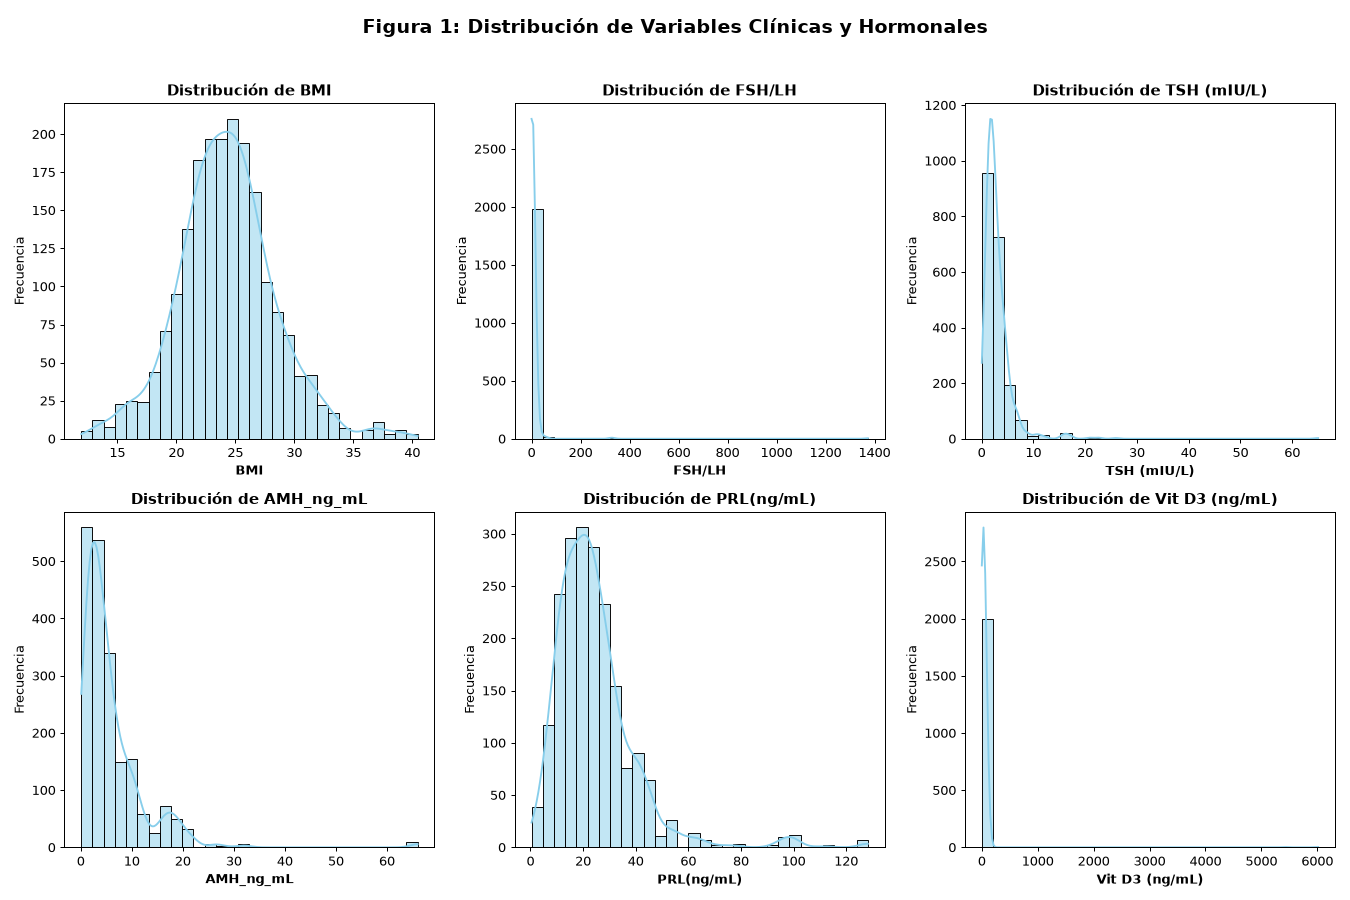

In [ ]:
plt.figure(figsize=(15, 10))
columnas = [
    "BMI",
    "FSH/LH",
    "TSH (mIU/L)",
    "AMH_ng_mL",
    "PRL(ng/mL)",
    "Vit D3 (ng/mL)"
]

for i, col in enumerate(columnas, 1):
    plt.subplot(2, 3, i)
    sns.histplot(
        data=df,
        x=col,
        kde=True,
        color="skyblue",
        bins=30
    )
    plt.title(f"Distribución de {col}", fontsize=12, fontweight="bold")
    plt.xlabel(col, fontsize=10, fontweight="bold")
    plt.ylabel("Frecuencia", fontsize=10)


plt.suptitle("Figura 1: Distribución de Variables Clínicas y Hormonales", fontsize=15, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(images_dir / "histograma_variables_clinicas.png", dpi=300)
plt.show()

### Inferencias del Análisis Histográfico Univariado

Al analizar los histogramas y curvas de densidad (KDE) de las seis variables de interés (**Figura 1**), destacan patrones claros sobre el comportamiento de los datos y errores severos de captura/calidad:

---

#### 1. Variables con Distribución Aceptable / Fisiológica
* **`BMI` (Índice de Masa Corporal):** Presenta una distribución aproximadamente **normal/simétrica**, centrada alrededor de $24 - 26 \text{ kg/m}^2$, con un rango fisiológico coherente (~13 a 40).
* **`AMH_ng_mL` (Hormona Antimülleriana):** Presenta un **sesgo positivo (hacia la derecha)**. La mayoría de los datos se concentran por debajo de $10 \text{ ng/mL}$, con una cola larga que llega hasta casi $65 \text{ ng/mL}$ (atípicos elevados característicos del fenotipo PCOS).
* **`PRL(ng/mL)` (Prolactina):** Muestra una distribución unimodal con ligero sesgo a la derecha, concentrando la mayor densidad entre $15$ y $30 \text{ ng/mL}$, con algunos valores atípicos hacia los $100 - 120 \text{ ng/mL}$.

---

#### 2. Variables con Anomalías Críticas (Atípicos Extremos / Errores de Datos)
* **`Vit D3 (ng/mL)`:** Su gráfica está totalmente comprimida hacia la izquierda debido a **valores atípicos masivos y no fisiológicos** que alcanzan hasta $6,000 \text{ ng/mL}$ (un valor real normal suele ser $< 100 \text{ ng/mL}$). Esto indica un error de captura o unidades en algunos registros.
* **`FSH/LH`:** Ocurre un fenómeno similar; la gráfica se comprime contra el origen porque existen valores extremos absolutos de hasta **1,400**. La relación FSH/LH fisiológica raramente supera valores de 10-20.
* **`TSH (mIU/L)`:** Concentra la gran mayoría de sus observaciones entre $0$ y $5 \text{ mIU/L}$, pero presenta una cola muy extendida hasta $65 \text{ mIU/L}$ (casos de hipotiroidismo severo o atípicos).

---

### Análisis de la Variable Objetivo: Distribución Diagnóstica de PCOS

Como se ilustra en el gráfico de pastel (**Figura 2: Distribución de PCOS**), el análisis de la variable dependiente `PCOS (Y/N)` sobre la cohorte total de $N = 2,000$ pacientes revela la siguiente estructura muestral:

* **Población Control (Sin PCOS):** Representa el **69.6%** de la muestra total (**$n = 1,392$ pacientes**), constituyendo la clase mayoritaria dentro del *dataset*.
* **Población Caso (Con PCOS):** Corresponde al **30.4%** de la muestra (**$n = 608$ pacientes**), representando a las pacientes con diagnóstico clínico confirmado de Síndrome de Ovario Poliquístico.

#### Implicaciones Estadísticas y Metodológicas

1. **Balance de Clases (Relación ~7:3):** La distribución refleja un leve desbalance de clases. Sin embargo, con un volumen de $n = 608$ casos positivos, la muestra cuenta con una **potencia estadística óptima** para realizar pruebas de hipótesis no paramétricas (como *Mann-Whitney U*) y comparaciones de distribuciones univariadas entre ambos subgrupos.
2. **Consideración para Modelado Predictivo:** Aunque el desbalance no es extremo (no requiere necesariamente técnicas complejas de resuestreo como *SMOTE*), es recomendable evaluar las métricas de rendimiento mediante el área bajo la curva ROC (**ROC-AUC**) o el **F1-Score** en lugar de *Accuracy* simple durante las etapas de validación de modelos.

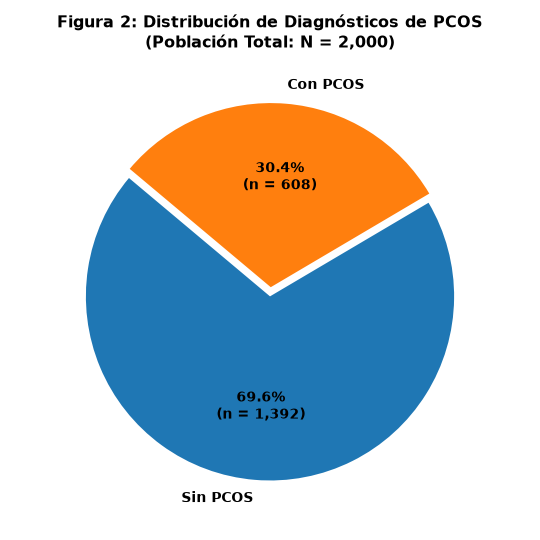

In [ ]:
import matplotlib.pyplot as plt

# Obtener conteos absolutos
counts = df["PCOS (Y/N)"].value_counts().rename({0: "Sin PCOS", 1: "Con PCOS"})

# Función para mostrar porcentaje y cantidad de pacientes (n) en cada sector
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f'{pct:.1f}%\n(n = {val:,})'
    return my_autopct

# Generar Pie Chart con mejor formato visual
plt.figure(figsize=(6, 6))
counts.plot(
    kind="pie",
    autopct=make_autopct(counts),
    startangle=140,
    colors=["#1f77b4", "#ff7f0e"],
    explode=(0, 0.05), # Destacar ligeramente el sector "Con PCOS"
    textprops={'fontsize': 11, 'weight': 'bold'},
    ylabel=""
)

plt.title("Figura 2: Distribución de Diagnósticos de PCOS\n(Población Total: N = 2,000)", fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(images_dir / "distribucion_diagnostico_pcos.png", dpi=300)
plt.show()

### Distribución por Edad de las Pacientes

El análisis histográfico de la variable de edad (**Figura 3**) muestra la estructura demográfica del grupo de estudio:

* **Comportamiento de la Distribución:** Presenta una distribución **unimodal con sesgo positivo (a la derecha)**, situando el pico de densidad entre los **25 y 35 años**.
* **Relevancia Clínica:** Este rango concentra la mayoría de los diagnósticos, lo cual concuerda con la etapa de mayor búsqueda de atención médica por infertilidad, irregularidades menstruales o sintomatología metabólica asociada a la edad reproductiva.
* **Dispersión:** Se observa una disminución progresiva en la frecuencia hacia las edades extremas del rango de estudio, manteniendo la representatividad en el grupo de mayor interés diagnóstico.

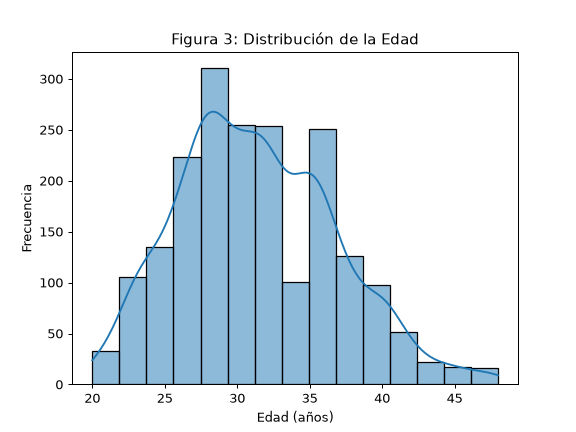

In [ ]:
sns.histplot(data=df, x="Age (yrs)", kde=True, bins=15)

plt.title("Figura 3: Distribución de la Edad")
plt.xlabel("Edad (años)")
plt.ylabel("Frecuencia")
plt.savefig(images_dir / "distribucion_edad.png", dpi=300)
plt.show()

## Análisis Bivariado

A través de esta sección evaluamos formalmente la interacción entre los marcadores fisiológicos, hormonales y antropométricos con respecto a la variable objetivo (`PCOS (Y/N)`). El propósito central es validar si existen diferencias estadísticamente significativas entre el grupo control (**Sin PCOS**) y el grupo clínico (**Con PCOS**), identificando las variables con mayor capacidad de discriminación diagnóstica.

---

### Objetivos Principales del Enfoque Bivariado

* **Comparación de Distribuciones:** Determinar la separación en las medidas de tendencia central (mediana e IQR) de las variables hormonales clave entre pacientes con y sin el padecimiento.
* **Evaluación de Asociación y Correlación:** Evaluar la co-ocurrencia de características clínicas (por ejemplo, la relación entre el incremento de BMI y la alteración de parámetros como la `AMH` o el cociente `FSH/LH`).
* **Identificación de Variables Candidatas:** Seleccionar las métricas con mayor contraste intergrupal para nutrir la fase posterior de modelado predictivo y selección de características (*feature selection*).



### Relación Antropométrica: Altura, Peso e Índice de Masa Corporal (BMI)

En este diagramas de dispersión (*Scatter Plot*) (**Figura 4**) se analiza la relación entre la estatura (`Height(Cm)`), el peso corporal (`Weight (Kg)`) y la escala de `BMI` (codificada por color y tamaño de punto).

* **Correlación Positiva y Dispersión:** Se observa una tendencia positiva clara entre el peso y la altura. Sin embargo, la dispersión vertical en cada nivel de estatura muestra que la variación de peso determina fuertemente el cambio en las categorías de `BMI`.
* **Gradiente de BMI:** La codificación cromática demuestra matemáticamente cómo el incremento en la relación peso/estatura al cuadrado ($\text{BMI} = \text{peso} / \text{estatura}^2$) desplaza a las pacientes hacia tonalidades amarillas ($\text{BMI} \ge 35$), asociadas con un mayor grado de obesidad.
* **Detección de Anomalías Antropométricas:** 
  * Se observan casos atípicos en la esquina superior izquierda (estaturas menores a $140\text{ cm}$ con pesos por encima de $60-70\text{ kg}$), derivando en un `BMI` significativamente elevado ($>35$).
  * En la parte superior ($>100\text{ kg}$) destacan pacientes con valores extremos de masa corporal, representantes de obesidad severa dentro de la muestra.



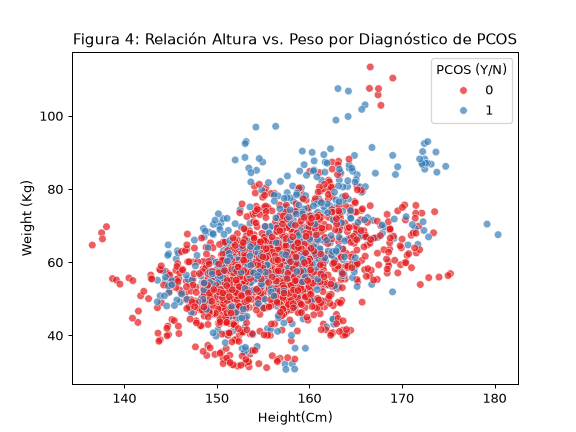

In [ ]:
sns.scatterplot(
    data=df,
    x="Height(Cm)",
    y="Weight (Kg)",
    hue="PCOS (Y/N)",  
    palette="Set1",
    alpha=0.7
)
plt.title("Figura 4: Relación Altura vs. Peso por Diagnóstico de PCOS")
plt.savefig(images_dir / "altura_vs_peso_pcos.png", dpi=300)
plt.show()

### Análisis Bivariado: Longitud del Ciclo Menstrual y su Valor Diagnóstico

La regularidad del ciclo menstrual es uno de los criterios clínicos fundamentales (Criterios de Rotterdam) para la sospecha y diagnóstico del Síndrome de Ovario Poliquístico. Fisiológicamente, un ciclo eumenorreico (regular) tiene una duración promedio de $28 \pm 7$ días, mientras que las pacientes con PCOS suelen presentar **oligomenorrea** (ciclos $> 35$ días) o **amenorrea** (ausencia prolongada de menstruación).

---

### Duración del Sangrado Menstrual según la Regularidad Reportada

Se analizó la distribución de la duración del sangrado (`Cycle length(days)`) en función del patrón de regularidad menstrual (`Cycle(R/I)`) (**Figura 5**), identificando variaciones clínicas significativas entre ambos grupos:

* **Pacientes con Ciclos Irregulares (Categoría 4):**
  * Presentan una **mediana de 4 días de sangrado**, pero exhiben una **alta dispersión y variabilidad** (rango intercuartílico de 3 a 6 días y vigotales extendidos de 0 a 10 días).
  * Se observan valores atípicos extremos desde **0 días** (compatibles con cuadros de **amenorrea**) hasta **11-12 días** (indicativos de **metrorragia o sangrado uterino disfuncional**), alteraciones altamente asociadas al entorno hormonal anovulatorio del PCOS.

* **Pacientes con Ciclos Regulares (Categoría 2):**
  * Muestran un comportamiento notablemente homogéneo con una **mediana constante de 5 días de sangrado**.
  * Los valores atípicos se acotan en un rango estrecho de **3 a 7 días**, lo cual se alinea perfectamente con la ventana fisiológica eumenorreica esperada.

---

#### Implicación Clínica
La variabilidad extrema en los días de sangrado resulta ser un marcador indirecto de anovulación. La presencia de amenorrea (0 días) y hemorragias prolongadas ($>10$ días) dentro de la cohorte irregular refuerza la relevancia del patrón del ciclo como una variable sintomática de alto peso predictivo para la clasificación del PCOS.

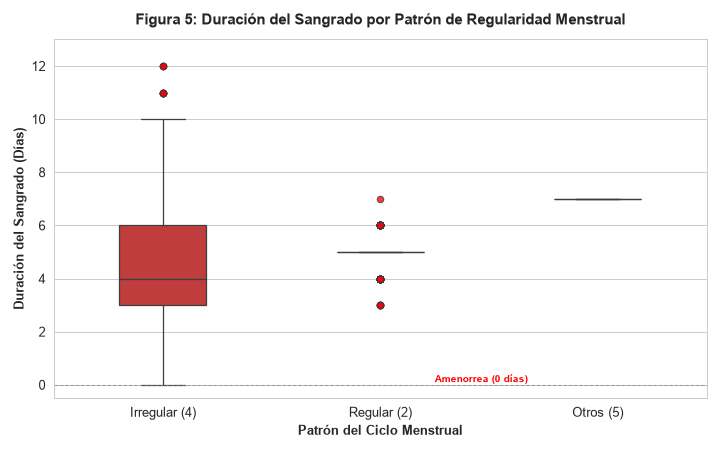

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Asegurar conversión numérica
df["Cycle length(days)"] = pd.to_numeric(df["Cycle length(days)"], errors="coerce")

# 2. Mapear códigos numéricos a etiquetas clínicas reales
cycle_map = {2: "Regular (2)", 4: "Irregular (4)", 5: "Otros (5)"}
df_plot = df.dropna(subset=["Cycle(R/I)", "Cycle length(days)"]).copy()
df_plot["Cycle_Label"] = df_plot["Cycle(R/I)"].map(cycle_map)

# 3. Configuración del gráfico
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")

ax = sns.boxplot(
    data=df_plot,
    x="Cycle_Label",
    y="Cycle length(days)",
    hue="Cycle_Label",
    palette={"Regular (2)": "#2ca02c", "Irregular (4)": "#d62728", "Otros (5)": "#7f7f7f"},
    width=0.4,
    fliersize=5,
    flierprops={"marker": "o", "markerfacecolor": "red", "alpha": 0.5}
)

# 4. Títulos y etiquetas profesionales
plt.title("Figura 5: Duración del Sangrado por Patrón de Regularidad Menstrual", fontsize=12, fontweight="bold", pad=12)
plt.xlabel("Patrón del Ciclo Menstrual", fontsize=10, fontweight="bold")
plt.ylabel("Duración del Sangrado (Días)", fontsize=10, fontweight="bold")
plt.ylim(-0.5, 13)

# 5. Anotaciones de apoyo clínico
plt.axhline(y=0, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
plt.text(1.25, 0.1, "Amenorrea (0 días)", color="red", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.savefig(images_dir / "duracion_sangrado_ciclo.png", dpi=300)
plt.show()

### Análisis Bivariado: Hormona Antimülleriana (AMH) por Diagnóstico de PCOS

El análisis bivariado mediante **Boxplot** (**Figura 6**) y **Violin Plot** (**Figura 7**) confirma la marcada elevación de la Hormona Antimülleriana (`AMH(ng/mL)`) en el grupo con diagnóstico positivo (`Con PCOS`), consolidándola como una de las variables continuas con mayor capacidad de separación en el dataset.

---

### Principales Hallazgos Estadísticos e Interpretación

* **Desplazamiento del Rango Intercuartílico (IQR):**
  * **Sin PCOS:** Presenta una distribución notablemente compacta en la base, con una **mediana de ~3.3 ng/mL** y un límite superior del IQR que no supera los **5.8 ng/mL**.
  * **Con PCOS:** La caja se desplaza hacia arriba de forma drástica, mostrando una **mediana de ~6.5 ng/mL** y una dispersión intercuartílica extendida hasta los **11.0 ng/mL**, lo que refleja la acumulación excesiva de folículos antrales retenidos.

* **Estructura de Densidad (Violin Plot):**
  * El gráfico de violín revela que, mientras la masa poblacional del grupo **Sin PCOS** está casi totalmente concentrada por debajo de $5\text{ ng/mL}$, la cohorte **Con PCOS** posee un cuerpo "ensanchado" en el rango de $5\text{ a }15\text{ ng/mL}$.
  * Ambas distribuciones muestran una cola derecha delgada, evidenciando subpoblaciones con hiperandrogenismo ovárico severo o reserva folicular hiperplásica.

* **Identificación de Anomalía Crítica (Outlier Ailslado):**
  * Se ratifica la presencia de una observación extrema de **~66 ng/mL** dentro del grupo con PCOS. La forma alargada del violín hacia la cúspide ilustra cómo este único valor distorsiona el eje vertical del dataset.


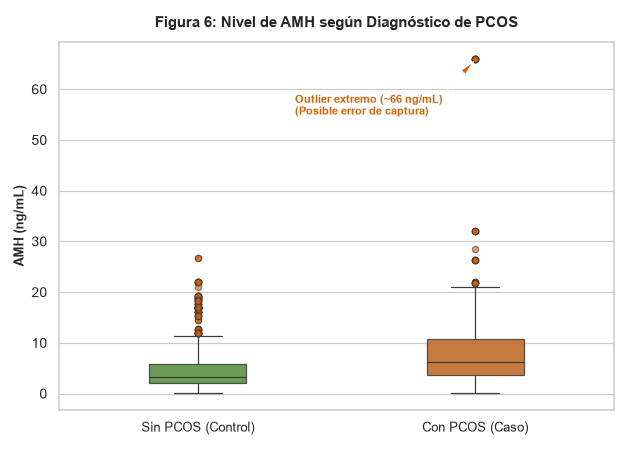

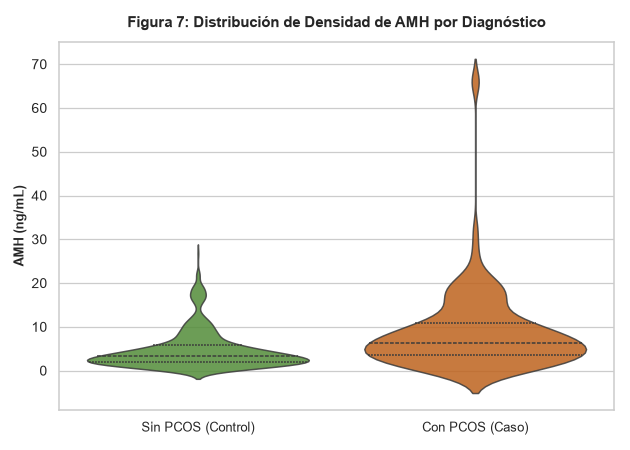

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo global
sns.set_theme(style="whitegrid")
palette_pcos = {0: "#4C9A2A", 1: "#D95F02"}

## Box-plot
plt.figure(figsize=(7, 5))

ax1 = sns.boxplot(
    data=df_plot,
    x="PCOS (Y/N)",
    y="AMH_ng_mL",
    hue="PCOS (Y/N)",
    palette=palette_pcos,
    width=0.35,
    boxprops=dict(alpha=0.85),
    flierprops=dict(
        marker="o",
        markerfacecolor="#D95F02",
        alpha=0.6,
        markersize=5
    ),
    legend=False
)

plt.title("Figura 6: Nivel de AMH según Diagnóstico de PCOS", fontsize=12, fontweight="bold", pad=12)
plt.xlabel("")
plt.ylabel("AMH (ng/mL)", fontsize=10, fontweight="bold")
plt.xticks([0, 1], ["Sin PCOS (Control)", "Con PCOS (Caso)"], fontsize=10)

# Anotación sobre el outlier extremo
plt.annotate(
    "Outlier extremo (~66 ng/mL)\n(Posible error de captura)",
    xy=(1, 65.8),
    xytext=(0.35, 55),
    arrowprops=dict(facecolor="#D95F02", shrink=0.05, width=1, headwidth=5),
    fontsize=8.5,
    fontweight="bold",
    color="#D95F02"
)

# Violin-plot
plt.tight_layout()
plt.savefig(images_dir / "amh_vs_pcos_boxplot_clean.png", dpi=300)
plt.show()

plt.figure(figsize=(7, 5))

ax2 = sns.violinplot(
    data=df_plot,
    x="PCOS (Y/N)",
    y="AMH_ng_mL",
    hue="PCOS (Y/N)",
    palette=palette_pcos,
    inner="quartile",
    linewidth=1.2,
    alpha=0.85,
    legend=False
)

plt.title("Figura 7: Distribución de Densidad de AMH por Diagnóstico", fontsize=12, fontweight="bold", pad=12)
plt.xlabel("")
plt.ylabel("AMH (ng/mL)", fontsize=10, fontweight="bold")
plt.xticks([0, 1], ["Sin PCOS (Control)", "Con PCOS (Caso)"], fontsize=10)

plt.tight_layout()
plt.savefig(images_dir / "amh_vs_pcos_violin_clean.png", dpi=300)
plt.show()

## Análisis de Rasgos Cualitativos por Diagnóstico de PCOS

A través de esta sección analizamos la prevalencia de las principales manifestaciones dermatológicas y fenotípicas reportadas en la evaluación física. Estos hallazgos cualitativos representan la expresión clínica directa del hiperandrogenismo y la hiperinsulinemia compensatoria, pilares fisiopatológicos del Síndrome de Ovario Poliquístico.

---

### Rasgos Clínicos de Interés

* **Hirsutismo (`hair growth(Y/N)`):** Crecimiento excesivo de vello en zonas andrógeno-dependientes debido a la sobreproducción ovárica de testosterona.
* **Alopecia (`hair fall(Y/N)`):** Pérdida de cabello de patrón femenino secundaria al efecto de la dihidrotestosterona (DHT).
* **Acné (`Pimple(Y/N)`):** Hiperactividad de las glándulas sebáceas estimulada por andrógenos libres.
* **Acantosis Nigricans (`Skin darkening (Y/N)`):** Oscurecimiento y engrosamiento cutáneo en pliegues, altamente correlacionado con la resistencia a la insulina.
* **Ganancia de Peso (`Weight gain(Y/N)`):** Tendencia al aumento ponderal de predominio visceral asociado a la disfunción metabólica.


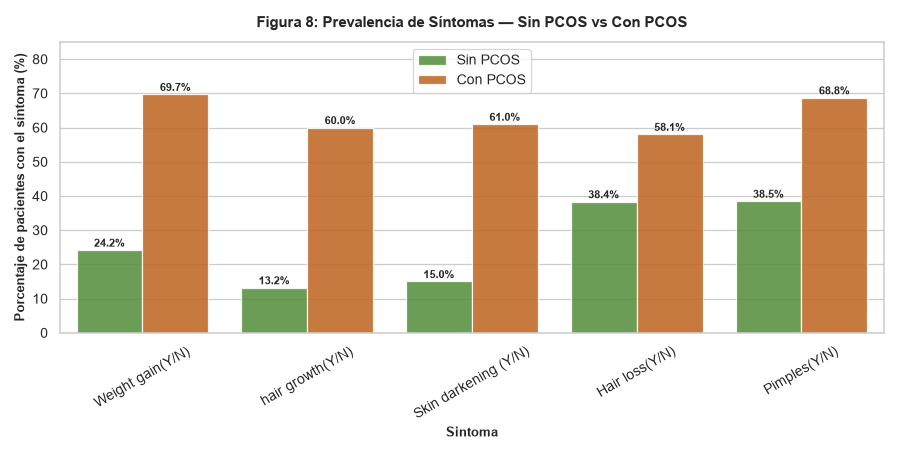

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.patches import Rectangle

# 1. Variables con los nombres exactos de tu dataset
sintomas_cols = [
    "Weight gain(Y/N)",
    "hair growth(Y/N)",
    "Skin darkening (Y/N)",
    "Hair loss(Y/N)",
    "Pimples(Y/N)"
]

# 2. Calcular porcentaje medio por grupo (0 = Sin PCOS, 1 = Con PCOS)
df_porcentajes = (df.groupby("PCOS (Y/N)")[sintomas_cols].mean() * 100).T.reset_index()

# 3. Transformar a formato largo para Seaborn sin alterar las etiquetas originales
df_melted = pd.melt(
    df_porcentajes, 
    id_vars=["index"], 
    value_vars=[0, 1], 
    var_name="PCOS (Y/N)", 
    value_name="Porcentaje"
)
df_melted["PCOS (Y/N)"] = df_melted["PCOS (Y/N)"].map({0: "Sin PCOS", 1: "Con PCOS"})

# 4. Gráfico de barras comparativo
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=df_melted,
    x="index",
    y="Porcentaje",
    hue="PCOS (Y/N)",
    palette={"Sin PCOS": "#4C9A2A", "Con PCOS": "#D95F02"},
    alpha=0.85
)

# Etiquetas de porcentaje exacto sobre cada barra
for p in ax.patches:
    if isinstance(p, Rectangle):
        height = p.get_height()
        if height > 0:
            ax.annotate(
                f"{height:.1f}%",
                (p.get_x() + p.get_width() / 2.0, height),
                ha="center",
                va="center",
                xytext=(0, 5),
                textcoords="offset points",
                fontsize=8.5,
                fontweight="bold"
            )

# Configuración de ejes y títulos
plt.title("Figura 8: Prevalencia de Síntomas — Sin PCOS vs Con PCOS", fontsize=12, fontweight="bold", pad=12)
plt.ylabel("Porcentaje de pacientes con el síntoma (%)", fontsize=10, fontweight="bold")
plt.xlabel("Sintoma", fontsize=10, fontweight="bold")
plt.ylim(0, 85)
plt.xticks(rotation=30)
plt.legend(title="")
plt.tight_layout()
plt.savefig(images_dir / "prevalencia_sintomas_labels_originales.png", dpi=300)
plt.show()

### Comparativa de Sintomatología Cualitativa

El análisis contrastado (**Figura 8**) entre el grupo control y las pacientes con PCOS demuestra variaciones marcadas en el valor predictivo de cada síntoma:

* **Síntomas de Alta Especificidad (Baja prevalencia en grupo sano):**
  * **Hirsutismo:** Pasa de **13.2%** en controles a **59.8%** en casos.
  * **Acantosis Nigricans:** Pasa de **14.9%** a **60.8%**. La baja presencia de estos rasgos en pacientes sanas los convierte en los predictores cualitativos más sólidos para la detección de hiperandrogenismo y resistencia a la insulina.

* **Síntomas de Alta Sensibilidad pero Inespecíficos:**
  * **Alopecia y Acné:** Aunque afectan a cerca del **60% y 68%** de los casos positivos respectivamente, presentan prevalencias cercanas al **38%** en el grupo control. Esto implica que no deben utilizarse aisladamente como criterio diagnóstico principal.

---

## Conclusion:

Mediante estas herramientas estadísticas podemos confirmar las complejas relaciones 
que existen en este padecimiento. El PCOS no solo se diagnostica por la presencia de 
múltiples quistes en los ovarios; como pudimos ver, existe una relación muy compleja 
entre el metabolismo de cada paciente y cómo este deriva en un cuadro positivo para 
PCOS. En el análisis de IMC se describió que el aumento de peso no está relacionado 
únicamente con la dieta, sino también con la producción de hormonas sexuales que 
normalmente se generan en menor cantidad. Estas hormonas son producidas a través de 
los ovarios y las glándulas suprarrenales. Otro dato muy importante es la observación 
de cómo la AMH tiene una relación directa con el diagnóstico de PCOS: las pacientes 
con PCOS presentan una mediana de AMH aproximadamente el doble que las pacientes sin 
PCOS (~7 vs ~3 ng/mL). Por último, la duración del sangrado en pacientes con ciclos 
irregulares también es un factor importante para el diagnóstico, ya que aquellas con 
períodos muy cortos o muy largos (~0 a ~12 días) mostraban claramente un desequilibrio 
en la producción de estrógeno y progesterona.

Por último, me gustaría agregar que es muy importante analizar este tipo de datos 
debido a la complejidad de este padecimiento multifactorial. No se puede diagnosticar 
únicamente por la presencia de quistes ováricos, sino a través de una red de síntomas 
y condiciones que solo se confirman en conjunto. Gracias al estudio de este padecimiento 
se ha llegado a la conclusión de que proviene de procesos metabólicos y hormonales, 
razón por la cual se ha propuesto renombrar el síndrome de PCOS a un nombre que refleje 
mejor su naturaleza metabólica y endocrina.